In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation

# === Function 1: SegFormer road segmentation ===
def segment_road_with_segformer(image_path):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError("Check the image path!")
    
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)

    # Load SegFormer
    # extractor = SegformerFeatureExtractor.from_pretrained("nvidia/segformer-b5-finetuned-cityscapes-1024-1024")
    # model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b5-finetuned-cityscapes-1024-1024")
    extractor = SegformerFeatureExtractor.from_pretrained("nvidia/segformer-b5-finetuned-cityscapes-1024-1024")
    model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b5-finetuned-cityscapes-1024-1024")

    inputs = extractor(images=image_pil, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    seg = outputs.logits.argmax(dim=1)[0].cpu().numpy()

    # Extract and resize road mask (class 0)
    road_mask = (seg == 0).astype(np.uint8) * 255
    road_mask_resized = cv2.resize(road_mask, (image_bgr.shape[1], image_bgr.shape[0]), interpolation=cv2.INTER_NEAREST)

    return image_rgb, road_mask_resized


# === Function 2: Generate red mask from image ===
# def generate_red_mask(image_bgr, min_area=500):
#     hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

#     lower_red1 = np.array([0, 40, 50])
#     upper_red1 = np.array([10, 255, 255])
#     lower_red2 = np.array([170, 70, 50])
#     upper_red2 = np.array([180, 255, 255])

#     mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
#     mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
#     red_mask = cv2.bitwise_or(mask1, mask2)

#     kernel = np.ones((3, 3), np.uint8)
#     cleaned = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel, iterations=1)

#     filtered_mask = np.zeros_like(cleaned)
#     contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     for cnt in contours:
#         if cv2.contourArea(cnt) > min_area:
#             cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)

#     return filtered_mask

def generate_red_mask(image_bgr, min_area=300, use_lab=True):
    # Convert to HSV
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    
    # Red range in HSV (wider range for pink/orange tint)
    lower_red1 = np.array([0, 50, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 50, 50])
    upper_red2 = np.array([180, 255, 255])

    mask_hsv1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask_hsv2 = cv2.inRange(hsv, lower_red2, upper_red2)
    red_mask_hsv = cv2.bitwise_or(mask_hsv1, mask_hsv2)

    # Optionally combine with LAB for better robustness
    if use_lab:
        lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
        A = lab[:, :, 1]
        B = lab[:, :, 2]

        mask_lab = cv2.inRange(A, 140, 200) & cv2.inRange(B, 130, 180)
        red_mask = cv2.bitwise_or(red_mask_hsv, mask_lab)
    else:
        red_mask = red_mask_hsv

    # Morphological filtering with a longer kernel
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3))
    cleaned = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Filter by contour area
    filtered_mask = np.zeros_like(cleaned)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_area:
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = max(w, h) / (min(w, h) + 1e-5)
            if aspect_ratio > 2:  # Keep long shapes only
                cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    return filtered_mask

# Test
# def generate_red_mask(image_bgr, min_area=300):
#     """
#     Generate a red/orange/yellow mask using CLAHE enhancement and a wide HSV threshold range.
#     Filters small noise using contour area thresholding.
    
#     Args:
#         image_bgr (np.ndarray): Original BGR image.
#         min_area (int): Minimum contour area to keep.

#     Returns:
#         filtered_mask (np.ndarray): Final cleaned binary mask of red-orange line regions.
#     """
#     Step 1: CLAHE contrast enhancement
#     lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
#     l, a, b = cv2.split(lab)
#     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
#     l_clahe = clahe.apply(l)
#     lab_clahe = cv2.merge((l_clahe, a, b))
#     enhanced_bgr = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

#     Step 2: HSV conversion and wide red-orange-yellow range
#     hsv = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2HSV)
#     lower_hue = np.array([0, 15, 20])
#     upper_hue = np.array([35, 255, 255])  # up to yellow-orange

#     mask = cv2.inRange(hsv, lower_hue, upper_hue)

#     Step 3: Morphological cleaning
#     kernel = np.ones((3, 3), np.uint8)
#     cleaned = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
#     cleaned = cv2.dilate(cleaned, kernel, iterations=1)

#     Step 4: Contour filtering
#     filtered_mask = np.zeros_like(cleaned)
#     contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     for cnt in contours:
#         if cv2.contourArea(cnt) > min_area:
#             cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)

#     return filtered_mask

# === Function 3: Extract only red-on-road areas ===
def extract_red_on_road(red_mask, road_mask):
    return cv2.bitwise_and(red_mask, road_mask)

/home/wins057/miniconda3/envs/python_ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# image_path = r"D:\\Master\\python-for-dl-homework\\week13\\redline_images\\2.png"
image_path = r"/home/wins057/Documents/Projects/python-for-dl-homework/week16/dataset/image/illegal_parking/B1021114/frame_00176.jpg"
# Step 1: Road segmentation with SegFormer
image_rgb, road_mask = segment_road_with_segformer(image_path)

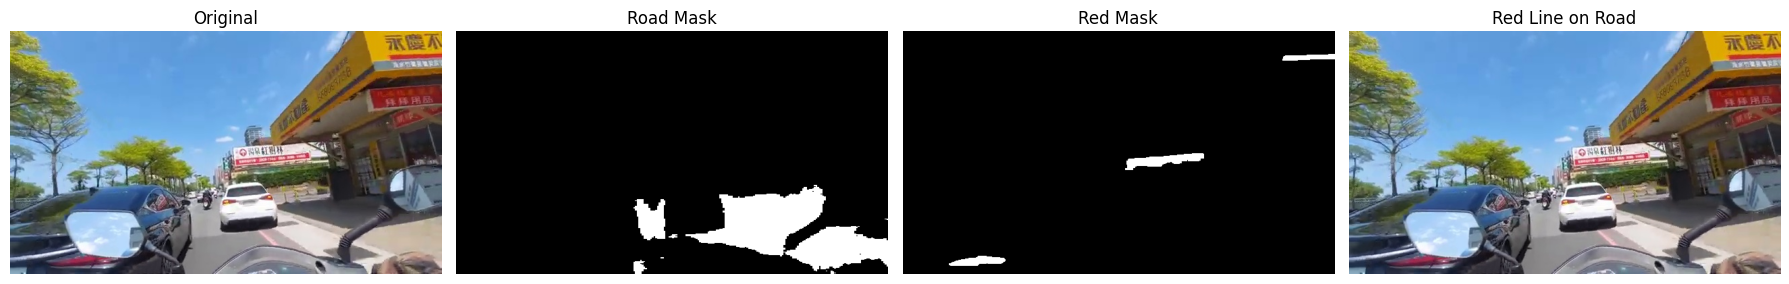

In [11]:
# === Example usage ===

# Step 2: Generate red mask from original BGR
image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
red_mask = generate_red_mask(image_bgr)

# Step 3: Mask red with road segment
red_on_road_mask = extract_red_on_road(red_mask, road_mask)

# Step 4: Overlay results
highlighted = image_rgb.copy()
highlighted[red_on_road_mask > 0] = [255, 0, 0]  # Mark in blue

# === Visualization ===
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.title("Original")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Road Mask")
plt.imshow(road_mask, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Red Mask")
plt.imshow(red_mask, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Red Line on Road")
plt.imshow(highlighted)
plt.axis("off")

plt.tight_layout()
plt.show()

Processing: /home/wins057/Documents/Projects/python-for-dl-homework/week13/redline_images/1.png


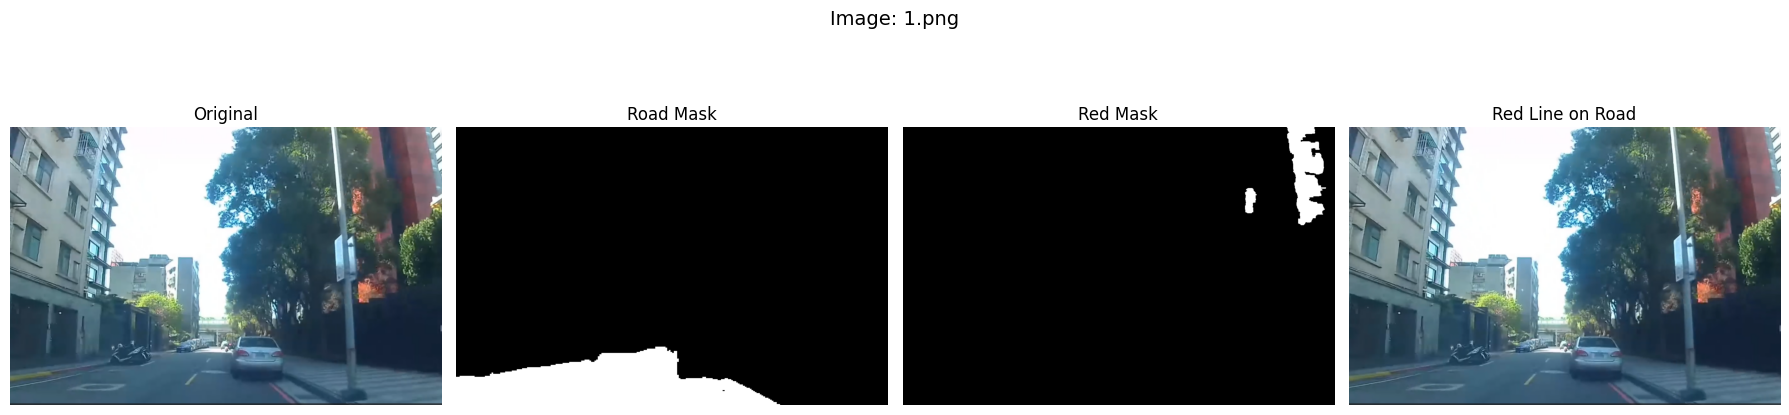

Processing: /home/wins057/Documents/Projects/python-for-dl-homework/week13/redline_images/2.png


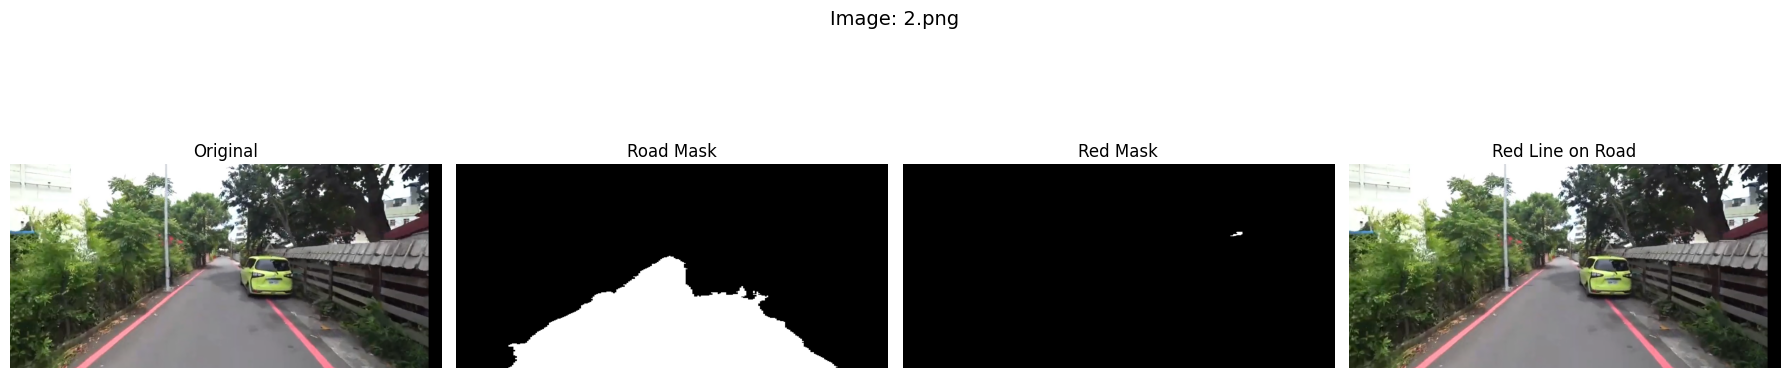

Processing: /home/wins057/Documents/Projects/python-for-dl-homework/week13/redline_images/3.png


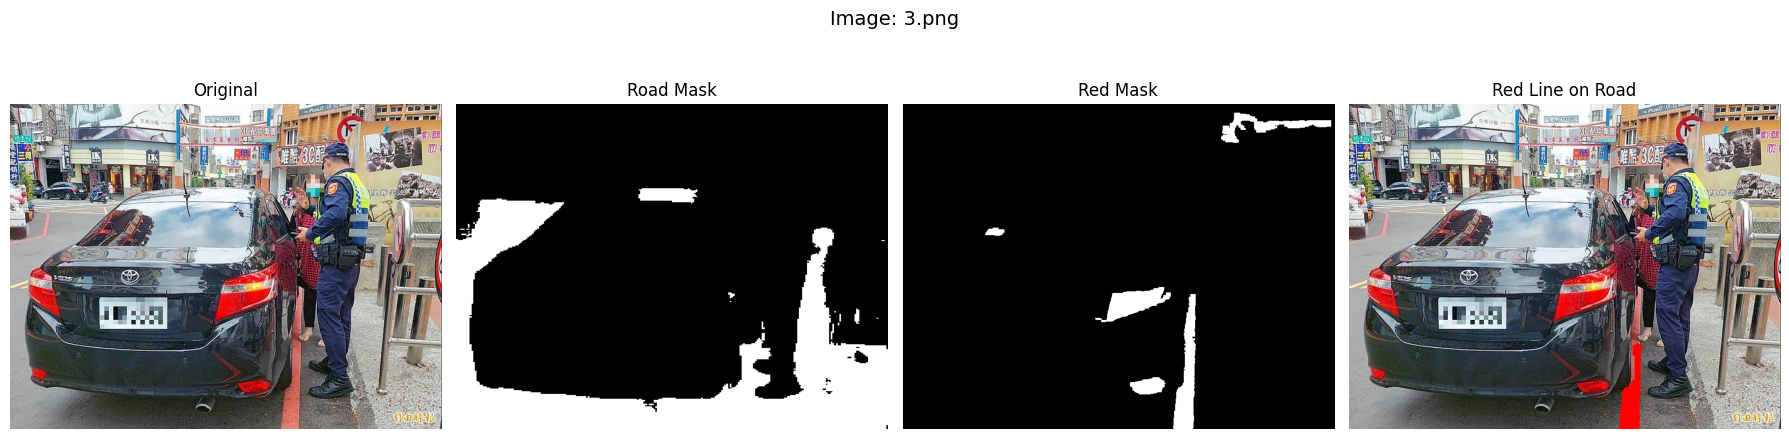

Processing: /home/wins057/Documents/Projects/python-for-dl-homework/week13/redline_images/4.png


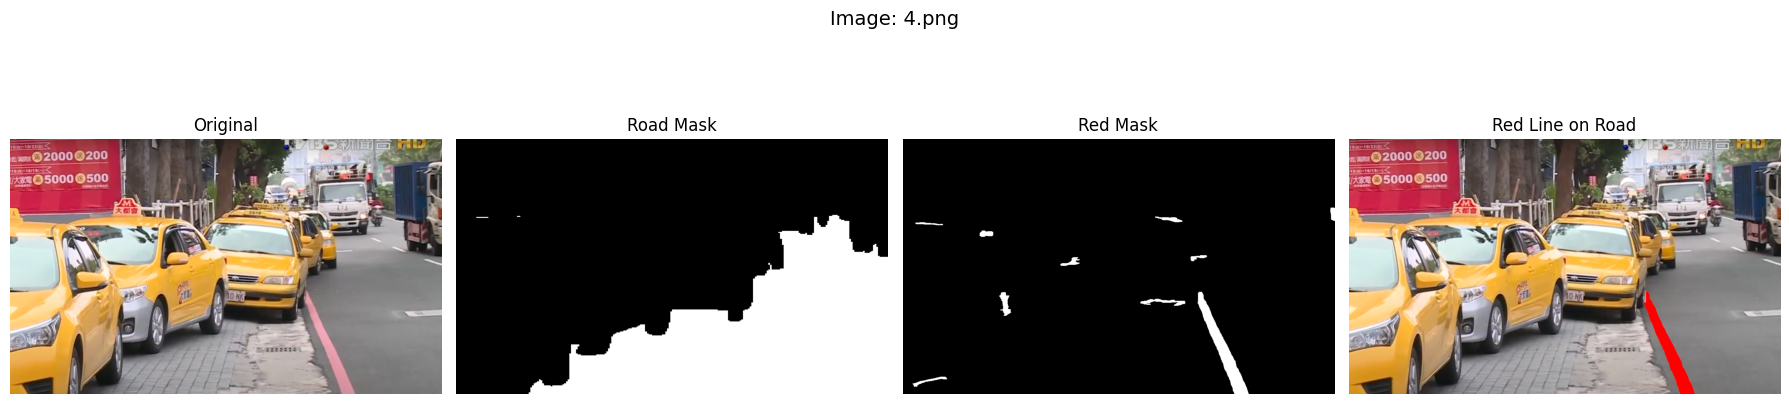

Processing: /home/wins057/Documents/Projects/python-for-dl-homework/week13/redline_images/5.jpg


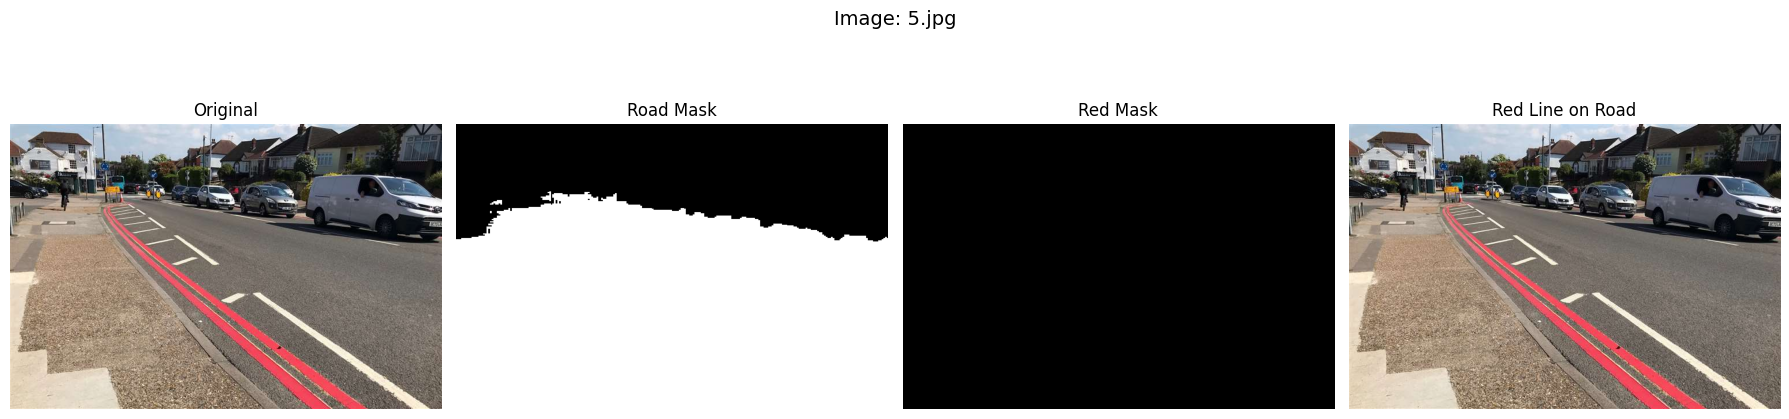

Processing: /home/wins057/Documents/Projects/python-for-dl-homework/week13/redline_images/6.jpg


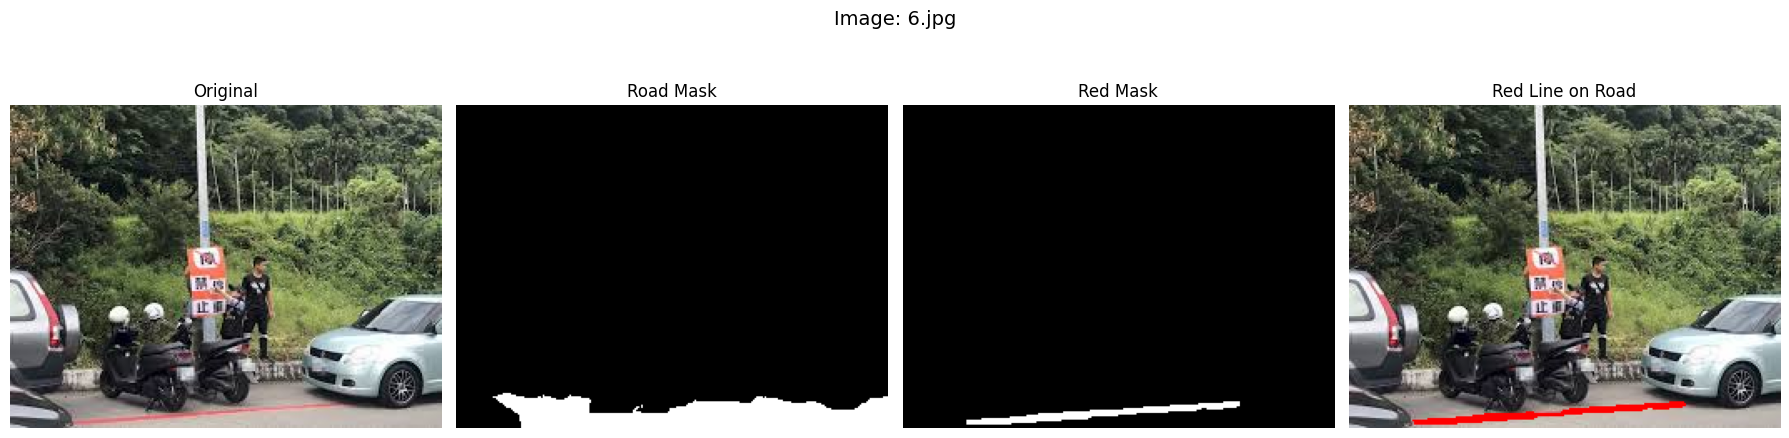

In [7]:
# === Load and process 6 images from folder ===
image_folder = r"/home/wins057/Documents/Projects/python-for-dl-homework/week13/redline_images"
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_files = sorted(image_files)[:6]  # Limit to first 6 images

for img_name in image_files:
    image_path = os.path.join(image_folder, img_name)
    print(f"Processing: {image_path}")

    image_rgb, road_mask = segment_road_with_segformer(image_path)
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    red_mask = generate_red_mask(image_bgr)
    red_on_road_mask = extract_red_on_road(red_mask, road_mask)

    highlighted = image_rgb.copy()
    highlighted[red_on_road_mask > 0] = [255, 0, 0]

    # Display
    plt.figure(figsize=(18, 5))
    plt.suptitle(f"Image: {img_name}", fontsize=14)

    plt.subplot(1, 4, 1)
    plt.title("Original")
    plt.imshow(image_rgb)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Road Mask")
    plt.imshow(road_mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Red Mask")
    plt.imshow(red_mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Red Line on Road")
    plt.imshow(highlighted)
    plt.axis("off")

    plt.tight_layout()
    plt.show()